In [30]:
import pandas as pd

employees = pd.DataFrame({
    'EmpID': [1,2,3,4,5,6,7,8,9,10],
    'City': ['Rajkot','Mumbai','Pune','Delhi','Mumbai',
             'Rajkot','Pune','Delhi','Mumbai','Rajkot'],
    'Education': ['Bachelors','Masters','PhD','Bachelors','Masters',
                  'PhD','Bachelors','Masters','PhD','Bachelors'],
    'ExperienceLevel': ['Junior','Mid','Senior','Junior','Mid',
                        'Senior','Junior','Mid','Senior','Junior'],
    'Age': [23,29,41,26,33,47,24,31,45,22],
    'Salary': [32000,48000,85000,35000,52000,
               91000,30000,49000,88000,29000]
})

print(employees)

   EmpID    City  Education ExperienceLevel  Age  Salary
0      1  Rajkot  Bachelors          Junior   23   32000
1      2  Mumbai    Masters             Mid   29   48000
2      3    Pune        PhD          Senior   41   85000
3      4   Delhi  Bachelors          Junior   26   35000
4      5  Mumbai    Masters             Mid   33   52000
5      6  Rajkot        PhD          Senior   47   91000
6      7    Pune  Bachelors          Junior   24   30000
7      8   Delhi    Masters             Mid   31   49000
8      9  Mumbai        PhD          Senior   45   88000
9     10  Rajkot  Bachelors          Junior   22   29000


In [12]:
#exercise 1
# City---Nominal — cities have no natural order

# Education---Ordinal — Bachelors < Masters < PhD

# Experience Level---Ordinal — Junior < Mid < Senior

# Age---Continuous

# Salary---Continuous

In [13]:
#exercise 2
# One-hot encode City using pandas
from sklearn.preprocessing import OneHotEncoder

city_dummies = pd.get_dummies(employees['City'], prefix='City')
print(city_dummies)
print(city_dummies.shape)


encoder = OneHotEncoder(sparse_output=False)
city_sklearn = encoder.fit_transform(employees[['City']])
print(city_sklearn)
print(encoder.get_feature_names_out())
print(employees['City'].nunique())


   City_Delhi  City_Mumbai  City_Pune  City_Rajkot
0       False        False      False         True
1       False         True      False        False
2       False        False       True        False
3        True        False      False        False
4       False         True      False        False
5       False        False      False         True
6       False        False       True        False
7        True        False      False        False
8       False         True      False        False
9       False        False      False         True
(10, 4)
[[0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]
['City_Delhi' 'City_Mumbai' 'City_Pune' 'City_Rajkot']
4


In [14]:
#exercise 3
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
employees['City_Label']=le.fit_transform(employees['City'])
print(employees[['City','City_Label']])

     City  City_Label
0  Rajkot           3
1  Mumbai           1
2    Pune           2
3   Delhi           0
4  Mumbai           1
5  Rajkot           3
6    Pune           2
7   Delhi           0
8  Mumbai           1
9  Rajkot           3


In [15]:
#LabelEncoder creates an artificial order among cities. A Linear Regression model may incorrectly assume that Rajkot (3) 
# is greater than Pune (2), which has no real meaning.

In [16]:
# exercise 4
from sklearn.preprocessing import OrdinalEncoder
encoder1=OrdinalEncoder(categories=[['Bachelors','Masters','PhD']])
employees['Education_Encoded']=encoder1.fit_transform(employees[['Education']])
print(employees[['Education','Education_Encoded']])

encoder2=OrdinalEncoder(
    categories=[['Junior','Mid','Senior']]
)
employees['Experience_Encoded']=encoder2.fit_transform(employees[['ExperienceLevel']])
print("\n",employees[['ExperienceLevel','Experience_Encoded']])

   Education  Education_Encoded
0  Bachelors                0.0
1    Masters                1.0
2        PhD                2.0
3  Bachelors                0.0
4    Masters                1.0
5        PhD                2.0
6  Bachelors                0.0
7    Masters                1.0
8        PhD                2.0
9  Bachelors                0.0

   ExperienceLevel  Experience_Encoded
0          Junior                 0.0
1             Mid                 1.0
2          Senior                 2.0
3          Junior                 0.0
4             Mid                 1.0
5          Senior                 2.0
6          Junior                 0.0
7             Mid                 1.0
8          Senior                 2.0
9          Junior                 0.0


In [17]:
#if categories are not mentioned then ordinal will take aalphbetila order

In [19]:
#exercise 5
from sklearn.preprocessing import MinMaxScaler,StandardScaler

minmax=MinMaxScaler()
employees_minmax=pd.DataFrame(minmax.fit_transform(employees[['Age','Salary']]),
                              columns=['Age_mm','Salary_mm'])
standard=StandardScaler()
employees_standard=pd.DataFrame(
    standard.fit_transform(employees[['Age','Salary']]),
    columns=['Age_z','Salary_z']
)

print(pd.concat([employees_minmax.round(3),employees_standard.round(3)]))

   Age_mm  Salary_mm  Age_z  Salary_z
0    0.04      0.048    NaN       NaN
1    0.28      0.306    NaN       NaN
2    0.76      0.903    NaN       NaN
3    0.16      0.097    NaN       NaN
4    0.44      0.371    NaN       NaN
5    1.00      1.000    NaN       NaN
6    0.08      0.016    NaN       NaN
7    0.36      0.323    NaN       NaN
8    0.92      0.952    NaN       NaN
9    0.00      0.000    NaN       NaN
0     NaN        NaN -1.039    -0.926
1     NaN        NaN -0.354    -0.249
2     NaN        NaN  1.016     1.315
3     NaN        NaN -0.697    -0.799
4     NaN        NaN  0.103    -0.080
5     NaN        NaN  1.701     1.568
6     NaN        NaN -0.925    -1.010
7     NaN        NaN -0.126    -0.207
8     NaN        NaN  1.473     1.441
9     NaN        NaN -1.153    -1.053


In [ ]:
# For KNN, StandardScaler is preferred because KNN is distance-based and 
# Salary values contain large variations. StandardScaler is less sensitive to 
# extreme values than MinMaxScaler.

In [21]:
#exercise 6
employees['CareerStage']=pd.cut(employees['Age'],
                                bins=[0,25,35,50],
                                labels=['Early Career','Mid Career','Senior Career'])
employees['SalaryBand'] = pd.qcut(
    employees['Salary'],
    q=3,
    labels=['Low','Medium','High']
)
print(employees)

print(employees['CareerStage'].value_counts())

print()

print(employees['SalaryBand'].value_counts())

   EmpID    City  Education ExperienceLevel  Age  Salary  City_Label  \
0      1  Rajkot  Bachelors          Junior   23   32000           3   
1      2  Mumbai    Masters             Mid   29   48000           1   
2      3    Pune        PhD          Senior   41   85000           2   
3      4   Delhi  Bachelors          Junior   26   35000           0   
4      5  Mumbai    Masters             Mid   33   52000           1   
5      6  Rajkot        PhD          Senior   47   91000           3   
6      7    Pune  Bachelors          Junior   24   30000           2   
7      8   Delhi    Masters             Mid   31   49000           0   
8      9  Mumbai        PhD          Senior   45   88000           1   
9     10  Rajkot  Bachelors          Junior   22   29000           3   

   Education_Encoded  Experience_Encoded    CareerStage SalaryBand  
0                0.0                 0.0   Early Career        Low  
1                1.0                 1.0     Mid Career     Medium  


In [ ]:
#pd.qut will split the data more evenly 

In [32]:
#exercise 7

from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
city_encoded = pd.get_dummies(
    employees['City'],
    prefix='City'
)

edu_encoder = OrdinalEncoder(
    categories=[['Bachelors','Masters','PhD']]
)
employees['Education_Encoded'] = edu_encoder.fit_transform(
    employees[['Education']]
)

exp_encoder = OrdinalEncoder(
    categories=[['Junior','Mid','Senior']]
)
employees['Experience_Encoded'] = exp_encoder.fit_transform(
    employees[['ExperienceLevel']]
)

scaler = StandardScaler()
employees[['Age_z','Salary_z']] = scaler.fit_transform(
    employees[['Age','Salary']]
)

employees['CareerStage'] = pd.cut(
    employees['Age'],
    bins=[0,25,35,50],
    labels=['Early Career',
            'Mid Career',
            'Senior Career']
)

employees_final = pd.concat(
    [
        employees.drop(
            columns=['City',
                     'Education',
                     'ExperienceLevel']
        ),
        city_encoded
    ],
    axis=1
)

print(employees_final.head())
employees_final.to_csv('employees_feature_engineered.csv',index=False)

   EmpID  Age  Salary  Education_Encoded  Experience_Encoded     Age_z  \
0      1   23   32000                0.0                 0.0 -1.039135   
1      2   29   48000                1.0                 1.0 -0.353991   
2      3   41   85000                2.0                 2.0  1.016297   
3      4   26   35000                0.0                 0.0 -0.696563   
4      5   33   52000                1.0                 1.0  0.102772   

   Salary_z    CareerStage  City_Delhi  City_Mumbai  City_Pune  City_Rajkot  
0 -0.925700   Early Career       False        False      False         True  
1 -0.249390     Mid Career       False         True      False        False  
2  1.314579  Senior Career       False        False       True        False  
3 -0.798892     Mid Career        True        False      False        False  
4 -0.080312     Mid Career       False         True      False        False  


In [22]:
#exercise 7
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

print("Path to dataset files:", path)

c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 652k/652k [00:01<00:00, 640kB/s]

Extracting files...
Path to dataset files: C:\Users\heerm\.cache\kagglehub\datasets\wenruliu\adult-income-dataset\versions\2


In [ ]:
# Fields
# The dataset contains 16 columns
# Target filed: Income
# -- The income is divide into two classes: <=50K and >50K
# Number of attributes: 14
# -- These are the demographics and other features to describe a person

In [1]:
#STEP1
import pandas as pd

adult = pd.read_csv('adult.csv')
print(adult.head())

print("Shape of dataset:", adult.shape)
print(adult.columns)
print(adult.dtypes)

   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-per-week native-country incom

In [2]:
categorical_cols = adult.select_dtypes(include='object').columns

print("Categorical columns:")
print(categorical_cols)
for col in categorical_cols:
    print(col, ":", adult[col].nunique())

Categorical columns:
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')
workclass : 9
education : 16
marital-status : 7
occupation : 15
relationship : 6
race : 5
gender : 2
native-country : 42
income : 2


In [ ]:
# The Adult Income dataset comprises 48,842 rows and 15 variables. Some of the columns have categorical values 
# and hence will need to be encoded before applying machine learning algorithms on them. From those categorical variables, 
# the "native-country" variable has 42 different categories and is thus a high cardinality variable. Columns like this may cause
# an explosion of dimensionality using one-hot encoding.

In [3]:
#Step 2
X = adult.drop('income', axis=1)
y = adult['income']
categorical_cols = X.select_dtypes(include='object').columns
print("Columns before encoding:", X.shape[1])
X_encoded = pd.get_dummies(
    X,columns=categorical_cols
)
print("Columns after encoding:", X_encoded.shape[1])
print("New columns added:",X_encoded.shape[1] - X.shape[1])
print(X_encoded.head())
for i in categorical_cols:
    print(i, ":", adult[col].nunique(), "new columns")

Columns before encoding: 14
Columns after encoding: 108
New columns added: 94
   age  fnlwgt  educational-num  capital-gain  capital-loss  hours-per-week  \
0   25  226802                7             0             0              40   
1   38   89814                9             0             0              50   
2   28  336951               12             0             0              40   
3   44  160323               10          7688             0              40   
4   18  103497               10             0             0              30   

   workclass_?  workclass_Federal-gov  workclass_Local-gov  \
0        False                  False                False   
1        False                  False                False   
2        False                  False                 True   
3        False                  False                False   
4         True                  False                False   

   workclass_Never-worked  ...  native-country_Portugal  \
0              

In [ ]:
# There was an increment in the number of attributes following the encoding process. From the categorical attributes, 
# native-country had the maximum number of columns added (42), which shows high cardinality. Therefore, there is a need to 
# explore other forms of encodings that may have fewer feature generations.

In [4]:
country_freq = adult['native-country'].value_counts(normalize=True)
print(country_freq.head())

native-country
United-States    0.897424
Mexico           0.019471
?                0.017546
Philippines      0.006040
Germany          0.004218
Name: proportion, dtype: float64


In [5]:
adult['native_country_freq'] = adult['native-country'].map(country_freq)
print(adult[['native-country','native_country_freq']].head())

  native-country  native_country_freq
0  United-States             0.897424
1  United-States             0.897424
2  United-States             0.897424
3  United-States             0.897424
4  United-States             0.897424


In [6]:
rare_countries = country_freq[country_freq < 0.02].index
print(rare_countries)
print(adult['native-country'].nunique())
adult['native-country'] = (adult['native-country'].replace(rare_countries,'Other'))
print(adult['native-country'].nunique())

Index(['Mexico', '?', 'Philippines', 'Germany', 'Puerto-Rico', 'Canada',
       'El-Salvador', 'India', 'Cuba', 'England', 'China', 'South', 'Jamaica',
       'Italy', 'Dominican-Republic', 'Japan', 'Guatemala', 'Poland',
       'Vietnam', 'Columbia', 'Haiti', 'Portugal', 'Taiwan', 'Iran',
       'Nicaragua', 'Greece', 'Peru', 'Ecuador', 'France', 'Ireland',
       'Thailand', 'Hong', 'Cambodia', 'Trinadad&Tobago', 'Laos',
       'Outlying-US(Guam-USVI-etc)', 'Yugoslavia', 'Scotland', 'Honduras',
       'Hungary', 'Holand-Netherlands'],
      dtype='object', name='native-country')
42
2


In [9]:
#now oneHot encodoing 
X_rare = adult.drop('income', axis=1)
categorical_cols = X_rare.select_dtypes(include='object').columns
X_rare_encoded = pd.get_dummies(
    X_rare,
    columns=categorical_cols
)
print("Normal encoded columns:", X_encoded.shape[1])
print("Rare-grouping columns:", X_rare_encoded.shape[1])

Normal encoded columns: 108
Rare-grouping columns: 69


In [14]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(y_encoded)


model = LogisticRegression(max_iter=1000)
norml_encoded_scores = cross_val_score(
    model,
    X_encoded,
    y_encoded,
    cv=5,
    scoring='accuracy'
)

print(norml_encoded_scores)
print("Baseline Accuracy:", norml_encoded_scores.mean())

rare_scores=cross_val_score(
    model,
    X_rare_encoded,
    y_encoded,
    cv=5,
    scoring='accuracy'
)
print(rare_scores)
print("Rare Grouping Accuracy:", rare_scores.mean())

[0 0 1 ... 0 0 1]


c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

[0.84348449 0.84031119 0.84039722 0.84899672 0.8454136 ]
Baseline Accuracy: 0.8437206430040906


c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

[0.84614597 0.84102774 0.84326372 0.8507371  0.84838247]
Rare Grouping Accuracy: 0.8459114010296321


c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
X_hybrid = adult.drop(
    ['income', 'native-country'],axis=1
)
y = adult['income']
categorical_cols = X_hybrid.select_dtypes(include='object').columns

print(categorical_cols)

X_hybrid = pd.get_dummies(
    X_hybrid,columns=categorical_cols
)
print("norml columns:",
      X_encoded.shape[1])
print("Hybrid columns:",
      X_hybrid.shape[1])

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender'],
      dtype='object')
norml columns: 108
Hybrid columns: 67


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model = LogisticRegression(
    max_iter=1000
)
hybrid_scores = cross_val_score(
    model,
    X_hybrid,
    y_encoded,
    cv=5,
    scoring='accuracy'
)

print(hybrid_scores)
print("Hybrid Accuracy:",hybrid_scores.mean())

c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

[0.84020882 0.84860272 0.84121622 0.8490991  0.84633497]
Hybrid Accuracy: 0.8450923666759473


c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#Step 4
# The Adult Income dataset includes multiple categorical variables, one of which is the high cardinality variable 'native-country'.
# One-hot encoding on all categorical variables will drastically increase the feature space and thus, increase the complexity of 
# computation and model training. In this paper, we try to explore the effect of adopting a combined encoding technique in which one-hot
#  encoding is applied to low cardinality variables, whereas frequency encoding is used for the high cardinality variable 
#  'native-country'. Logistic regression will be our classification model for this problem statement.

In [21]:
print(adult.columns)
print(adult.shape)
print()

print(X_encoded.columns)
print(X_encoded.shape)
print()

print(X_hybrid)
print(X_hybrid.shape)
print()

print(X_rare_encoded)
print(X_rare.shape)


Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income', 'native_country_freq'],
      dtype='object')
(48842, 16)

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_?', 'workclass_Federal-gov',
       'workclass_Local-gov', 'workclass_Never-worked',
       ...
       'native-country_Portugal', 'native-country_Puerto-Rico',
       'native-country_Scotland', 'native-country_South',
       'native-country_Taiwan', 'native-country_Thailand',
       'native-country_Trinadad&Tobago', 'native-country_United-States',
       'native-country_Vietnam', 'native-country_Yugoslavia'],
      dtype='object', length=108)
(48842, 108)

       age  fnlwgt  educational-num  capital-gain  capital-loss  \
0       25  226802                7             0             0   
1

In [27]:
#Step5
results = pd.DataFrame({
    'Encoding Strategy':
    ['Full One-Hot Encoding',
     'Rare-grouping Encoding',
     'Hybrid Encoding'],

    'Number of Features':
    [X_encoded.shape[1],
     X_rare_encoded.shape[1],
     X_hybrid.shape[1]],

    'Cross-Validated Accuracy':
    [norml_encoded_scores.mean(),
     rare_scores.mean(),
     hybrid_scores.mean()]
})

print(results)

        Encoding Strategy  Number of Features  Cross-Validated Accuracy
0   Full One-Hot Encoding                 108                  0.843721
1  Rare-grouping Encoding                  69                  0.845911
2         Hybrid Encoding                  67                  0.845092


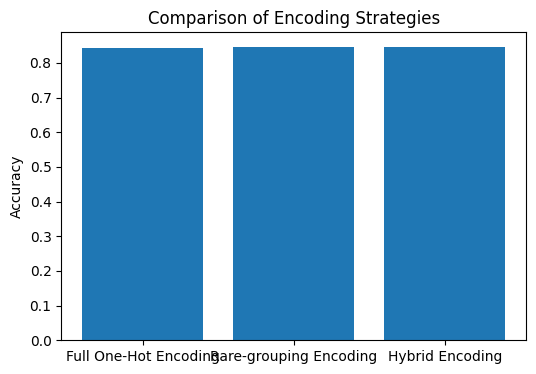

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(
    results['Encoding Strategy'],
    results['Cross-Validated Accuracy']
)

plt.ylabel('Accuracy')
plt.title('Comparison of Encoding Strategies')

plt.show()